<a href="https://colab.research.google.com/github/sahdahx/Komstat-II/blob/main/KomstatII_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas 2 - Komputasi Statistika II**
**Analisis Data Toko Buku Online**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

Link tugas: [sahdahx/Komstat-II](https://github.com/sahdahx/Komstat-II/blob/main/KomstatII_T2.ipynb)

# Studi Kasus

Suatu toko buku online dapat diakses melalui URL berikut: http://books.toscrape.com/

1. Ekstraksi Data: Gunakan requests dan BeautifulSoup untuk melakukan scraping pada halaman pertama dari URL tersebut (terdapat 20 buku). Ambil tiga informasi berikut untuk setiap buku:

   a. Judul Buku.

   b. Harga Buku (Abaikan simbol Poundsterling '£').

   c. Rating Buku (Dalam bentuk teks: One, Two, Three, Four, Five).

2. Transformasi Data: Masukkan data hasil scraping ke dalam pandas DataFrame.

   Lakukan pembersihan data (data cleaning):

   a. Ubah kolom Harga menjadi tipe data numerik (float).

   b. Ubah teks pada kolom Rating menjadi angka bulat murni (contoh: "One" menjadi 1, "Two" menjadi 2, dan seterusnya). Tipe datanya harus integer.

3. Gunakan matplotlib atau seaborn untuk membuat sebuah scatter plot. Tetapkan harga buku sebagai sumbu X (Variabel independen) dan rating buku sebagai sumbu Y
(Variabel dependen).

4. Akan diuji apakah buku yang lebih mahal cenderung memiliki rating yang lebih tinggi (atau sebaliknya).

   a. Buatlah model regresi linier sederhana.
   
   b. Buatlah model regresi polinomial derajat 2 (kuadratik), tampilkan nilai R 2 dari model polinomial ini.

   c. Plot scatter plot dari kedua model regresi tersebut (Linear dan Polinomial), jelaskan perbedaannya.

5. Manajemen ingin mengelompokkan buku menjadi kategori "Buku Premium" dan memprediksi peluang sebuah buku mendapat rating tertentu untuk masuk ke kategori
tersebut.

   a. Buat satu kolom baru di Data Frame bernama Buku_Premium. Jika Harga Buku ≥ 40, isi dengan nilai 1. Jika harga Buku < 40, isi dengan nilai 0.

   b. Buatlah model regresi logistik menggunakan variabel Rating Buku (X) untuk memprediksi probabilitas variabel Buku Premium (Y).

In [ ]:
# Import library
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [ ]:
# 1. EKSTRAKSI  DATA
# Request
url = "http://books.toscrape.com/"
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text,'html.parser')

# Ambil semua buku
books = soup.select('article.product_pod')

# Ekstraksi data
df = pd.DataFrame({
    'Judul':judul,
    'Harga':harga,
    'Rating':rating
})

In [ ]:
print("\n Struktur data sebelum cleaning:")
df.info()
print("\n Dataset sebelum cleaning:")
df


 Struktur data sebelum cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Judul   20 non-null     object
 1   Harga   20 non-null     object
 2   Rating  20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes

 Dataset sebelum cleaning:


,Judul,Harga,Rating
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five
5,The Requiem Red,£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,£22.60,Four
9,The Black Maria,£52.15,One


In [ ]:
# 2. TRANSFORMASI DATA
# Cleaning
rating_map = {'One':1,'Two':2,'Three':3,'Four':4,'Five':5}
df['Rating'] = df['Rating'].map(rating_map).astype(int)

In [ ]:
# Cleaning
harga = [b.select_one('.price_color').text for b in books]
df['Harga'] = (
    df['Harga']
    .str.replace('[^0-9.]','',regex=True)
    .astype(float)
)

In [ ]:
print("\n Struktur data setelah cleaning:")
df.info()
print("\n Dataset setelah cleaning:")
df


 Struktur data setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Judul   20 non-null     object 
 1   Harga   20 non-null     float64
 2   Rating  20 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 612.0+ bytes

 Dataset setelah cleaning:


,Judul,Harga,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5
5,The Requiem Red,22.65,1
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4
7,The Coming Woman: A Novel Based on the Life of...,17.93,3
8,The Boys in the Boat: Nine Americans and Their...,22.60,4
9,The Black Maria,52.15,1


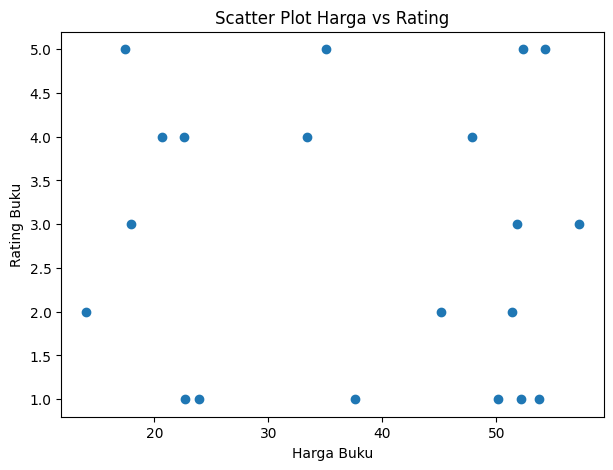

In [ ]:
# 3. SCATTER PLOT
plt.figure(figsize=(7,5))
plt.scatter(df['Harga'],df['Rating'])
plt.xlabel("Harga Buku")
plt.ylabel("Rating Buku")
plt.title("Scatter Plot Harga vs Rating")
plt.show()

In [ ]:
# 4. MODEL REGRESI
# Linear regression
X = df[['Harga']]
y = df['Rating']

linear_model = LinearRegression()
linear_model.fit(X,y)
y_linear = linear_model.predict(X)
y_linear

array([2.74235579, 2.72690128, 2.75545683, 2.77334327, 2.72305726,
       2.97080016, 2.88693785, 3.00782823, 2.9711924 , 2.73937472,
       3.03873725, 2.98641157, 3.01151534, 2.73827643, 2.87375837,
       2.69936558, 2.96115089, 2.8535969 , 2.74580756, 2.79413233])

In [ ]:
# Polynomial regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly,y)

y_poly = poly_model.predict(X_poly)
R2_poly = r2_score(y,y_poly)
print("Nilai R2 Polynomial:",R2_poly)

Nilai R2 Polynomial: 0.006451548468397905


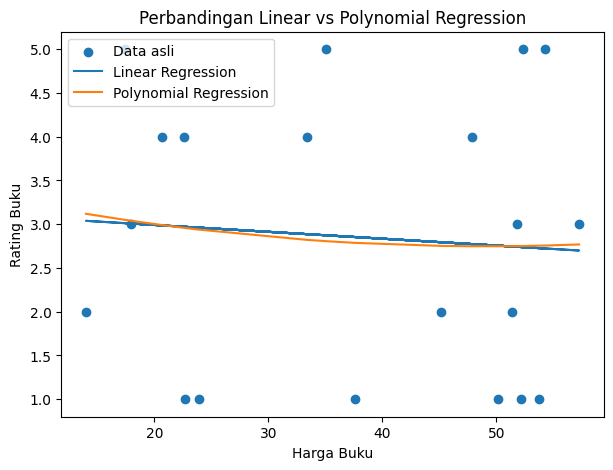

In [ ]:
# Plot perbandingan model
plt.figure(figsize=(7,5))
plt.scatter(df['Harga'],df['Rating'],label="Data asli")
plt.plot(df['Harga'],y_linear,label="Linear Regression")
urut = np.argsort(df['Harga'])

plt.plot(
    df['Harga'].iloc[urut],
    y_poly[urut],
    label="Polynomial Regression"
)
plt.xlabel("Harga Buku")
plt.ylabel("Rating Buku")
plt.title("Perbandingan Linear vs Polynomial Regression")
plt.legend()
plt.show()

**Perbedaan model:**

Model regresi linear menghasilkan garis lurus yang menunjukkan hubungan linear antara harga dan rating. Model polynomial derajat dua menghasilkan kurva yang lebih fleksibel sehingga dapat menangkap pola non-linear jika ada. Jika nilai R² polynomial lebih besar dari linear, maka model polynomial lebih baik dalam menjelaskan variasi data. Namun jika perbedaannya kecil, maka hubungan antara harga dan rating kemungkinan lemah.

In [ ]:
# 5. KATEGORI "BUKU PREMIUM"
# Buku premium
df['Buku_Premium'] = (df['Harga']>=40).astype(int)

# Logistic regression
## Variabel independen (X) dan dependen (Y)
x_new = df['Rating']
y_new = df['Buku_Premium']

## Menambahkan intercept
intercept = [1]*len(df)

## Gabungkan variabel penjelas
penjelas = pd.DataFrame({
    "intercept": intercept,
    "Rating": x_new
})

## Model regresi logistik
log_reg = sm.Logit(y_new, penjelas).fit()
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.688302
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:           Buku_Premium   No. Observations:                   20
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            1
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                0.006990
Time:                        14:18:42   Log-Likelihood:                -13.766
converged:                       True   LL-Null:                       -13.863
Covariance Type:            nonrobust   LLR p-value:                    0.6598
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3691      0.954      0.387      0.699      -1.500       2.238
Rating        -0.1295      0.

In [ ]:
X_log = df[['Rating']]
y_log = df['Buku_Premium']
log_model = LogisticRegression()
log_model.fit(X_log,y_log)
df['Prob_Premium'] = log_model.predict_proba(X_log)[:,1]
df

,Judul,Harga,Rating,Buku_Premium,Prob_Premium
0,A Light in the Attic,51.77,3,1,0.495534
1,Tipping the Velvet,53.74,1,1,0.554873
2,Soumission,50.10,1,1,0.554873
3,Sharp Objects,47.82,4,1,0.465807
4,Sapiens: A Brief History of Humankind,54.23,5,1,0.436321
5,The Requiem Red,22.65,1,0,0.554873
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,0,0.465807
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,0,0.495534
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,0,0.465807
9,The Black Maria,52.15,1,1,0.554873


## 1. Ekstraksi Data

Pada tahap ini dilakukan web scraping menggunakan library requests dan BeautifulSoup untuk mengambil data dari halaman pertama website books.toscrape.com yang berisi 20 buku. Informasi yang diambil meliputi `Judul`, `Harga`, dan `Rating`.

Proses scraping dilakukan dengan mengidentifikasi container setiap buku menggunakan tag HTML `article` dengan class `product_pod`. Judul diambil dari atribut title pada tag `<a>`, harga diambil dari tag dengan class `price_color`, dan rating diambil dari class kedua pada tag `star-rating`.

Hasil ekstraksi menunjukkan bahwa seluruh 20 data buku berhasil diambil tanpa missing value.

## 2. Transformasi Data

Data hasil scraping kemudian dimasukkan ke dalam pandas DataFrame untuk dilakukan pembersihan data.

Transformasi yang dilakukan:
- Variabel `Harga` dibersihkan dengan menghapus simbol mata uang dan karakter non numerik kemudian dikonversi menjadi tipe float.
- Variabel `Rating` diubah dari bentuk teks (One sampai Five) menjadi bilangan integer 1 sampai 5 menggunakan mapping dictionary.

Setelah cleaning, tipe data sudah sesuai, yaitu:
`Judul` bertipe object, `Harga` bertipe float, dan `Rating` bertipe integer.

## 3. Scatter Plot

Scatter plot dibuat untuk melihat hubungan antara `Harga` sebagai variabel independen (X) dan `Rating` sebagai variabel dependen (Y).

Berdasarkan visualisasi, terlihat bahwa titik data tersebar secara acak tanpa pola linear yang jelas. Hal ini menunjukkan bahwa tidak terdapat hubungan kuat antara harga buku dengan rating buku. Buku dengan harga tinggi tidak selalu memiliki rating tinggi dan sebaliknya.

## 4. Analisis Regresi

### a. Regresi Linear
Regresi linear digunakan untuk melihat apakah terdapat hubungan linear antara `Harga` dan `Rating`. Hasil prediksi menunjukkan nilai rating berada di sekitar nilai rata-rata (sekitar 2.7 sampai 3.0), yang menunjukkan bahwa pengaruh harga terhadap rating relatif kecil.

Kemiringan garis regresi yang sedikit menurun menunjukkan kecenderungan negatif yang sangat lemah, artinya semakin mahal harga buku tidak berarti rating semakin tinggi.

### b. Regresi Polinomial
Regresi polinomial derajat dua digunakan untuk melihat kemungkinan adanya hubungan non-linear. Nilai R² yang diperoleh sebesar 0.00645 menunjukkan bahwa model hanya mampu menjelaskan sekitar 0.6% variasi data.

Nilai R² yang sangat kecil menunjukkan bahwa harga hampir tidak memiliki kemampuan dalam menjelaskan variasi rating buku.

### c. Perbandingan Model
Dari plot perbandingan, terlihat bahwa garis regresi linear dan kurva polinomial hampir berimpit. Hal ini menunjukkan bahwa baik model linear maupun polynomial tidak mampu menangkap pola hubungan yang signifikan antara harga dan rating.

Kesimpulan dari kedua model adalah hubungan antara harga dan rating sangat lemah atau hampir tidak ada.

## 5. Klasifikasi Buku Premium

### a. Pembentukan Variabel Buku Premium
Variabel baru `Buku_Premium` dibuat dengan ketentuan:
- Jika `Harga` ≥ 40 maka bernilai 1.
- Jika `Harga` < 40 maka bernilai 0.

Variabel ini digunakan untuk mengelompokkan buku berdasarkan kategori harga.

### b. Regresi Logistik
Regresi logistik digunakan untuk memprediksi probabilitas sebuah buku masuk kategori premium berdasarkan `Rating`.

- Nilai intercept (`log-odds`) sebesar 0.3691 jika dikonversi ke bentuk probabilitas menghasilkan nilai sekitar 0.59. Hal ini menunjukkan bahwa ketika variabel rating bernilai nol, maka peluang sebuah buku masuk kategori premium diperkirakan sebesar 59%. Namun karena pada data tidak terdapat rating bernilai nol (rating hanya berkisar antara 1 sampai 5), maka nilai ini hanya berperan sebagai baseline model dan tidak memiliki interpretasi praktis secara langsung.
- Nilai odds ratio yang diperoleh sebesar 0.879. Nilai ini mengindikasikan bahwa setiap kenaikan satu poin rating cenderung menurunkan peluang (`odds`) sebuah buku termasuk kategori premium sekitar 12.1%. Karena nilai odds ratio kurang dari 1 tetapi cukup dekat dengan 1, maka dapat disimpulkan bahwa hubungan antara rating dan status buku premium bersifat negatif namun sangat lemah.
- Selain itu, nilai p-value sebesar 0.661 yang lebih besar dari tingkat signifikansi 0.05 menunjukkan bahwa variabel rating tidak memiliki pengaruh yang signifikan secara statistik terhadap kemungkinan sebuah buku masuk kategori premium.
- Dataset akhir menunjukkan bahwa probabilitas berada di kisaran sekitar 0.43 sampai 0.55. Nilai probabilitas yang relatif berdekatan menunjukkan bahwa rating bukan prediktor yang kuat untuk menentukan apakah sebuah buku termasuk premium atau tidak.

**Kesimpulan Umum:**

Berdasarkan seluruh analisis, dapat disimpulkan bahwa harga buku tidak memiliki hubungan yang signifikan dengan rating buku. Model regresi linear maupun polinomial menunjukkan hubungan yang sangat lemah, dan regresi logistik juga menunjukkan bahwa rating bukan prediktor yang kuat untuk menentukan apakah buku termasuk kategori premium. Oleh karena itu, buku dengan rating tinggi belum tentu memiliki harga mahal sehingga rating bukan faktor utama dalam menentukan kategori premium.

Hal ini menunjukkan bahwa faktor lain di luar harga kemungkinan lebih berpengaruh terhadap rating buku seperti kualitas konten, popularitas penulis, atau preferensi pembaca.